# Ongoing rate-modulated input to a single active human cell (middle temporal gyrus)

Based on **ElectricBrainSignals Figure-9.12**, heavily adapted:

- **One** active human L5 pyramidal cell, Allen model **`626170637`**
  (H16.06.010.01.03.05.03, middle temporal gyrus, spiny, intact apical; *perisomatic*
  biophysics = active soma, passive dendrites — the only kind Allen provides for human).
- **Uniformly distributed** excitatory synapses over the whole cell (no basal/apical/uniform
  waves).
- Each synapse is driven by an inhomogeneous Poisson train whose rate is **sinusoidally
  modulated at f = 20 Hz**. The drive is tuned so the cell **occasionally fires an action
  potential, near the peak** of the modulation.
- Simulation duration **~500 ms**.
- The cell is placed in the **middle temporal gyrus** of the New York head model and the
  EEG is computed there; the 3D head (panel E) is shown from a left-lateral view.
- The **laminar LFP** calculation/plot and the **EEG topography snapshots** (old panel H)
  have been removed.

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import LFPy
from lfpykit import CurrentDipoleMoment
from lfpykit.eegmegcalc import NYHeadModel
from brainsignals import neural_simulations as ns
from brainsignals.plotting_convention import simplify_axes, mark_subplots

np.random.seed(1234)

In [16]:
# ---------------------------------------------------------------------------
# Loader for Allen Cell Types biophysical models, adapted from
# simulations/inspect_allen_cell_model.py to use the brainsignals cell-model
# folder (ns.allen_folder). Downloads the model, compiles its .mod mechanisms,
# and builds an *active* LFPy.Cell (make_passive=False).
# ---------------------------------------------------------------------------
import sys
import ssl
import json
import shutil
import zipfile
import subprocess
from os.path import join
from urllib.request import urlopen

import neuron

hay_folder = ns.hay_folder
ns.load_mechs_from_folder(ns.cell_models_folder)

allen_folder = ns.allen_folder            # .../brainsignals/cell_models/allen
_loaded_mod_folders = set()

# Human pyramidal (middle temporal gyrus), perisomatic.
model_id = 626170637
model_id = 626170679

cell_name = f"allen_{model_id}"
cell_name = "hay"


def _nrnivmodl_bin():
    """Locate nrnivmodl. Prefer the console-script wrapper next to the running
    python; the copy under neuron/.data/bin has a build path baked in and fails."""
    cand = join(os.path.dirname(sys.executable), "nrnivmodl")
    if os.path.isfile(cand):
        return cand
    exe = shutil.which("nrnivmodl")
    if exe and os.path.isfile(exe):
        return exe
    raise RuntimeError("nrnivmodl not found")


def download_allen_model(model_id):
    """Download and unzip an Allen neuronal model into allen_folder."""
    model_id = str(model_id)
    zip_path = join(allen_folder, f"neuronal_model_{model_id}.zip")
    out_dir = join(allen_folder, f"neuronal_model_{model_id}")
    url = f"https://api.brain-map.org/neuronal_model/download/{model_id}"
    print("Downloading Allen model", model_id, "from", url)
    u = urlopen(url, context=ssl._create_unverified_context())
    with open(zip_path, "wb") as f:
        f.write(u.read())
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)
    os.remove(zip_path)
    return out_dir


def return_allen_cell_model(model_id, dt, tstop, make_passive=False):
    """Build an LFPy.Cell from an Allen Cell Types biophysical model.
    Tested previously against the AllenSDK/BMTK versions of the same models."""
    model_id = str(model_id)
    model_folder = join(allen_folder, f"neuronal_model_{model_id}")
    if not os.path.isdir(model_folder):
        download_allen_model(model_id)

    mod_folder = join(model_folder, "modfiles")
    if not os.path.isdir(join(mod_folder, "x86_64")):
        print("Compiling mechanisms ...")
        cwd = os.getcwd()
        os.chdir(mod_folder)
        try:
            subprocess.run([_nrnivmodl_bin()], check=True)
        finally:
            os.chdir(cwd)

    if mod_folder not in _loaded_mod_folders:
        neuron.load_mechanisms(mod_folder)
        _loaded_mod_folders.add(mod_folder)

    params = json.load(open(join(model_folder, "fit_parameters.json")))
    manifest = json.load(open(join(model_folder, "manifest.json")))
    metadata = json.load(open(join(model_folder, "model_metadata.json")))
    morph_file = join(model_folder, "reconstruction.swc")
    model_type = manifest["biophys"][0]["model_type"]

    Ra = params["passive"][0]["ra"]
    if model_type == "Biophysical - perisomatic":
        e_pas = params["passive"][0]["e_pas"]
        cms = params["passive"][0]["cm"]

    neuron.h.celsius = params["conditions"][0]["celsius"]
    reversal_potentials = params["conditions"][0]["erev"]
    active_mechs = params["genome"]

    cell_parameters = {
        'morphology': morph_file,
        'v_init': -70,
        'passive': False,
        'nsegs_method': 'fixed_length',
        'max_nsegs_length': 10.,
        'dt': dt,
        'tstart': -100,          # let the cell settle; recorders start at t=0
        'tstop': tstop,
        'pt3d': True,
        'extracellular': True,   # needed for imem
        'custom_code': [join(allen_folder, 'remove_axon.hoc')],
    }
    cell = LFPy.Cell(**cell_parameters)
    cell.metadata = metadata
    cell.manifest = manifest

    if make_passive and model_type != "Biophysical - perisomatic":
        raise RuntimeError("make_passive only implemented for perisomatic models")

    for sec in neuron.h.allsec():
        sec.insert("pas")
        sectype = sec.name().split("[")[0]
        if model_type == "Biophysical - perisomatic":
            sec.e_pas = e_pas
            for cm_dict in cms:
                if cm_dict["section"] == sectype:
                    exec("sec.cm = {}".format(cm_dict["cm"]))
        sec.Ra = Ra

        if not make_passive:
            for sec_dict in active_mechs:
                if sec_dict["section"] == sectype:
                    if not sec_dict["mechanism"] == "":
                        if not sec.has_membrane(sec_dict["mechanism"]):
                            sec.insert(sec_dict["mechanism"])
                    exec("sec.{} = {}".format(sec_dict["name"], sec_dict["value"]))
            for sec_dict in reversal_potentials:
                if sec_dict["section"] == sectype:
                    for key in sec_dict.keys():
                        if not key == "section":
                            exec("sec.{} = {}".format(key, sec_dict[key]))

    neuron.h.secondorder = 0
    ns.align_cell_to_axes(cell)   # PCA-align principal (apical) axis to +z
    return cell





def return_hay_cell(tstop, dt, make_passive=False):
    if not os.path.isfile(join(hay_folder, 'morphologies', 'cell1.asc')):
        ns.download_hay_model()


    if not hasattr(neuron.h, "CaDynamics_E2"):
        neuron.load_mechanisms(join(hay_folder, 'mod'))
    cell_params = {
        'morphology': join(hay_folder, "morphologies", "cell1.asc"),
        'templatefile': [join(hay_folder, 'models', 'L5PCbiophys3.hoc'),
                         join(hay_folder, 'models', 'L5PCtemplate.hoc')],
        'templatename': 'L5PCtemplate',
        'templateargs': join(hay_folder, 'morphologies', 'cell1.asc'),
        'passive': False,
        'nsegs_method': None,
        'dt': dt,
        'tstart': -200,
        'tstop': tstop,
        'v_init': -75,
        'celsius': 34,
        'pt3d': True,
        'extracellular': True,
    }

    cell = LFPy.TemplateCell(**cell_params)

    if make_passive:
        remove_list = ["Nap_Et2", "NaTa_t", "NaTs2_t", "SKv3_1", "SK_E2", "K_Tst", "K_Pst", "KdShu2007",
                       "Im", "Ih", "CaDynamics_E2", "Ca_LVAst", "Ca", "Ca_HVA", 'StochKv']
        ns.remove_active_mechanisms(remove_list, cell)

    cell.set_rotation(x=4.729, y=-3.166)
    return cell

def return_cell_model(tstop, dt, make_passive, cell_name):
    neuron.h("forall delete_section()")

    if cell_name == "hay":
        cell = return_hay_cell(tstop, dt,
                               make_passive=make_passive)
    elif "allen" in cell_name:
        cell_id = cell_name.split("_")[1]
        cell = return_allen_cell_model(cell_id, dt, tstop,
                                       make_passive=make_passive)

    else:
        raise ValueError(f"Did not recognize cell name: {cell_name}")

    return cell




def make_white_noise_stimuli(cell, input_idx, freqs, tvec, input_scaling=0.001):

    I = np.zeros(len(tvec))
    for freq in freqs:
        I += np.sin(2 * np.pi * freq * tvec/1000. + 2*np.pi*np.random.random())
    input_array = input_scaling * I

    noise_vec = neuron.h.Vector(input_array)

    i = 0
    syn = None
    for sec in cell.allseclist:
        for seg in sec:
            if i == input_idx:
                print("Input inserted in ", sec.name())
                syn = neuron.h.ISyn(seg.x, sec=sec)
            i += 1
    if syn is None:
        raise RuntimeError("Wrong stimuli index")
    syn.dur = 1E9
    syn.delay = 0
    noise_vec.play(syn._ref_amp, cell.dt)
    return cell, syn, noise_vec


def run_RT_based_simulation(cell_name, dt, tstop, input_idx, input_amp, freqs, tvec, lead_field):

    scale_factor = 1e-7
    cell = return_cell_model(cell_name=cell_name, dt=dt, tstop=tstop, make_passive=True)
    cell, syn, noise_vec =  make_white_noise_stimuli(cell, input_idx, freqs, tvec, -scale_factor*input_amp)

    cell.simulate(rec_vmem=True, rec_imem=True)
    p = CurrentDipoleMoment(cell).get_transformation_matrix() @ cell.imem
    eeg = lead_field @ p * 1E-9 / scale_factor
    eeg -= np.mean(eeg)

    # Find the effective input resistance of the cell, to later calculate equivalent somatic current input
    dV_ = cell.vmem[input_idx] - np.mean(cell.vmem[input_idx])
    dV_amp_ = np.max(np.abs(dV_))
    # From reciprocity, we now have the target dV from eeg, and the passive membrane potential response from a known current input.
    # From this we can calculate the somatic current input needed to mimic the target potential
    dV_amp_per_nA = dV_amp_ / (input_amp * scale_factor)
    equiv_i_amp = np.max(np.abs(eeg[0])) / dV_amp_per_nA

    print(f"Target dVm: {np.max(np.abs(eeg[0]))} mV")
    print(f"Equivalent somatic current input: {equiv_i_amp} nA")

    del cell, p, syn, noise_vec
    return eeg, equiv_i_amp



Mechanisms already loaded from path: /home/tone/work/celltype_ES/CellTypeDependenceElStim/simulations/ElectricBrainSignals/brainsignals/cell_models.  Aborting.


In [17]:
# Simulation / input parameters
dt = 2**-4
tstop = 500.0

n_tsteps_ = int((tstop) / dt + 1)
tvec = np.arange(n_tsteps_) * dt

f_mod = 20.0          # Hz, sinusoidal rate-modulation frequency
num_syns = 100      # uniformly distributed excitatory synapses
rate_mean = 5.0      # Hz, mean presynaptic rate per synapse
syn_weight = 0.0005   # uS (tuned so the cell occasionally fires near the peak)
mod_depth = 1.0        # sinusoidal modulation depth (0..1)


syn_params = {'e': 0.,
              'syntype': 'Exp2Syn',
              'tau1': 1., 'tau2': 3.,
              'weight': syn_weight,
              'record_current': False}
syn_params = {'e': 0.,
              'syntype': 'ExpSynI',
              'tau': 1., #'tau2': 3.,
              'weight': syn_weight * 1e3,
              'record_current': False}


# Random generator for the presynaptic spike trains (kept separate from the
# global numpy RNG that drives synapse placement, so both are reproducible).
spike_rng = np.random.RandomState(12345)


def modulated_spiketrain(rate_mean, f, tstop, rng, m=1.0):
    """Inhomogeneous-Poisson spike train (thinning).
    rate(t) = rate_mean * (1 + m * sin(2*pi*f*t)),  t in ms, rates in Hz."""
    lam_max = rate_mean * (1 + m)
    if lam_max <= 0:
        return np.array([])
    n_exp = rng.poisson(lam_max * tstop / 1000.0 * 1.5 + 10)
    t = np.sort(rng.uniform(0, tstop, size=n_exp))
    lam = rate_mean * (1 + m * np.sin(2 * np.pi * f * t / 1000.0))
    return t[rng.uniform(0, lam_max, size=t.size) < lam]

In [18]:
# --- New York head + MTG source, set up BEFORE the simulation so the cell can be
# --- rotated onto the cortical surface normal prior to simulating.


_nyhead_candidates = ["sa_nyhead.mat",
                      os.path.expanduser("~/work/NY_head/sa_nyhead.mat")]
_nyhead_file = next((pth for pth in _nyhead_candidates if os.path.isfile(pth)), None)
nyhead = NYHeadModel(nyhead_file=_nyhead_file)

cortex = nyhead.cortex
elecs = np.array(nyhead.elecs)
head_tri = np.array(nyhead.head_data["head"]["tri"]).T - 1
head_vc = np.array(nyhead.head_data["head"]["vc"])
cortex_tri = np.array(nyhead.head_data["cortex75K"]["tri"]).T - 1
x_ctx, y_ctx, z_ctx = cortex
x_h, y_h, z_h = head_vc[0, :], head_vc[1, :], head_vc[2, :]

eeg_elec_idx = 140
vertex_idx = np.argmax(np.abs(nyhead.lead_field_normal[:, eeg_elec_idx]))

# Keep the left-hemisphere electrodes (as before)
upper_idxs = np.where(elecs[1, :] > 0)[0]
#elecs = elecs[:, upper_idxs]
num_elecs = elecs.shape[1]


#eeg_elec_idx = 111
#dipole_loc = np.array([-70.9, -22.5, -13.1])  # left middle temporal gyrus (MNI mm)
#vertex_idx = np.argmin(np.sqrt(np.sum((dipole_loc[:, None] - cortex)**2, axis=0)))
# Closest electrode to the source
#eeg_elec_idx = np.argmin(np.sqrt(np.sum((cortex[:, vertex_idx, None] -
#                                         elecs[:3, :]) ** 2, axis=0)))




#eeg_elec_idx = np.argmin(np.sqrt(np.sum((cortex[:, vertex_idx, None] -
 #                                        elecs[:3, :]) ** 2, axis=0)))
dipole_loc = cortex[:, vertex_idx]            # snap to nearest cortex vertex
print("MTG source vertex:", np.round(dipole_loc, 1), "mm")
nyhead.set_dipole_pos(dipole_loc)
print("Vertex normal direction:", np.round(nyhead.cortex_normal_vec, 3))


print("Closest EEG electrode location:", elecs[:, eeg_elec_idx], eeg_elec_idx)

print("Max lead field: ", np.max(np.abs(nyhead.lead_field)))

tES_field = nyhead.lead_field[:, vertex_idx, eeg_elec_idx]
print("tES lead field (V/m): ",  nyhead.lead_field_normal[vertex_idx, eeg_elec_idx])


# Rotation that maps the cell's simulation z-axis onto the surface normal.
# LFPy set_rotation(x, y, z, 'xyz') applies Rz(z) Ry(y) Rx(x) to the geometry,
# so we decompose R_surf (the same matrix rotate_dipole_to_surface_normal uses)
# into those Euler angles.
R_surf = nyhead.rotate_dipole_to_surface_normal(np.eye(3))
rot_x = np.arctan2(R_surf[2, 1], R_surf[2, 2])
rot_y = np.arcsin(-np.clip(R_surf[2, 0], -1, 1))
rot_z = np.arctan2(R_surf[1, 0], R_surf[0, 0])

MTG source vertex: [36.2 35.8 44.9] mm
Vertex normal direction: [ 0.924  0.371 -0.099]
Closest EEG electrode location: [56.18941948 35.70948909 50.87911178  0.73613454  0.4529696   0.50291598] 140
Max lead field:  0.5209782901732667
tES lead field (V/m):  0.2062240837279731


In [20]:

input_idx = 0
input_amp = 4  # mA

stim_f = 5

cell_name = "hay"

eeg, equiv_i_amp = run_RT_based_simulation(cell_name, dt, tstop, input_idx, input_amp * 1e6, np.array([stim_f]), tvec, tES_field)

cell = return_cell_model(cell_name=cell_name, dt=dt, tstop=tstop, make_passive=True)

# Upright morphology + synapse locations, kept for the morphology panel (A)
cell_x_up, cell_z_up = cell.x.copy(), cell.z.copy()

# Uniformly distributed synapses over the whole cell (area-normalized).
zbot, ztop = cell.z.min(), cell.z.max()
syn_idxs = cell.get_rand_idx_area_norm(nidx=num_syns, z_min=zbot, z_max=ztop)
syn_pos_x = np.array([cell.x[int(i)].mean() for i in syn_idxs])
syn_pos_z = np.array([cell.z[int(i)].mean() for i in syn_idxs])

syn_spike_times = []
for sidx in syn_idxs:
    syn_params["idx"] = int(sidx)
    st = modulated_spiketrain(rate_mean, f_mod, tstop, spike_rng, m=mod_depth)
    syn_spike_times.append(st)

del cell





Input inserted in  L5PCtemplate[0].soma[0]
Target dVm: 5693.627040960769 mV
Equivalent somatic current input: 9.208900407790526e-05 nA


In [ ]:
# Rotate the cell onto the cortical surface normal BEFORE simulating, so its
# current dipole moment comes out already oriented in head coordinates
# (rot_x/rot_y/rot_z were computed in the MTG-setup cell above).
#cell.set_rotation(x=rot_x, y=rot_y, z=rot_z, rotation_order='xyz')



syn_spike_times = []
for idx, sidx in enumerate(syn_idxs):
    syn_params["idx"] = int(sidx)
    synapse = LFPy.Synapse(cell, **syn_params)
    st = syn_spike_times[idx]
    synapse.set_spike_times(st if st.size else np.array([-1.0]))


local_ext_pot = np.vectorize(lambda x, y, z: np.dot(np.array([x, y, z]).T, tES_field))  # mV
n_tsteps_ = int((tstop) / dt + 1)
t_ = np.arange(n_tsteps_) * dt

base_pot = local_ext_pot(
    cell.x.mean(axis=-1),
    cell.y.mean(axis=-1),
    cell.z.mean(axis=-1)
).reshape(cell.totnsegs, 1)

pulse = input_amp * np.sin(2 * np.pi * stim_f * t_ / 1000)
v_cell_ext = base_pot * pulse.reshape(1, n_tsteps_)
cell.insert_v_ext(v_cell_ext, t_)

print("Starting simulation")

cell.simulate(rec_vmem=True, rec_imem=True)

# Current dipole moment (already in head coordinates, since the cell was rotated)
p = CurrentDipoleMoment(cell).get_transformation_matrix() @ cell.imem

tvec = cell.tvec.copy()
somav = cell.somav.copy()
cell_x, cell_y, cell_z = cell.x.copy(), cell.y.copy(), cell.z.copy()

# somatic spike times (upward crossings of -20 mV)
_above = somav > -20.
ap_times = tvec[np.where((~_above[:-1]) & (_above[1:]))[0] + 1]
print(f"{len(ap_times)} somatic APs over {tstop:.0f} ms")

np.save("neural_data_human_active_mtg.npy",
        {"tvec": tvec, "somav": somav, "p": p, "ap_times": ap_times,
         "cell_x": cell_x, "cell_y": cell_y, "cell_z": cell_z,
         "cell_x_up": cell_x_up, "cell_z_up": cell_z_up,
         "syn_pos_x": syn_pos_x, "syn_pos_z": syn_pos_z,
         "syn_spike_times": np.array(syn_spike_times, dtype=object)},
        allow_pickle=True)
del cell

In [11]:
# EEG at the scalp. Because the cell was rotated onto the surface normal *before*
# simulating, its dipole moment p is already in head coordinates -- we do NOT call
# rotate_dipole_to_surface_normal here (that would rotate it a second time).
p_surf = p - np.mean(p, axis=1)[:, None]

eeg = nyhead.get_transformation_matrix() @ p_surf * 1e6   # nV
eeg = eeg[upper_idxs, :]

# Times of the modulation peaks (sin = +1)  ->  t = (0.25 + k) / f
peak_times = (0.25 + np.arange(int(np.ceil(tstop * f_mod / 1000.)))) * 1000. / f_mod
peak_times = peak_times[peak_times <= tstop]

In [12]:
# Helpers to draw the EEG-electrode discs on the 3D head (from Figure-9.12)
from mpl_toolkits.mplot3d import art3d
from matplotlib.patches import Circle


def rotation_matrix(d):
    sin_angle = np.linalg.norm(d)
    if sin_angle == 0:
        return np.identity(3)
    d = d / sin_angle
    eye = np.eye(3)
    ddt = np.outer(d, d)
    skew = np.array([[0, d[2], -d[1]],
                     [-d[2], 0, d[0]],
                     [d[1], -d[0], 0]], dtype=np.float64)
    return ddt + np.sqrt(1 - sin_angle**2) * (eye - ddt) + sin_angle * skew


def pathpatch_2d_to_3d(pathpatch, z=0, normal='z'):
    if type(normal) is str:
        index = "xyz".index(normal)
        normal = np.roll((1.0, 0, 0), index)
    normal = normal / np.linalg.norm(normal)
    path = pathpatch.get_path()
    trans = pathpatch.get_patch_transform()
    path = trans.transform_path(path)
    pathpatch.__class__ = art3d.PathPatch3D
    pathpatch._code3d = path.codes
    pathpatch._facecolor3d = pathpatch.get_facecolor
    verts = path.vertices
    d = np.cross(normal, (0, 0, 1))
    M = rotation_matrix(d)
    pathpatch._segment3d = np.array([np.dot(M, (x, y, 0)) + (0, 0, z) for x, y in verts])
    pathpatch._axlim_clip = False  # required by matplotlib >=3.10 Axes3D.draw


def pathpatch_translate(pathpatch, delta):
    pathpatch._segment3d += delta

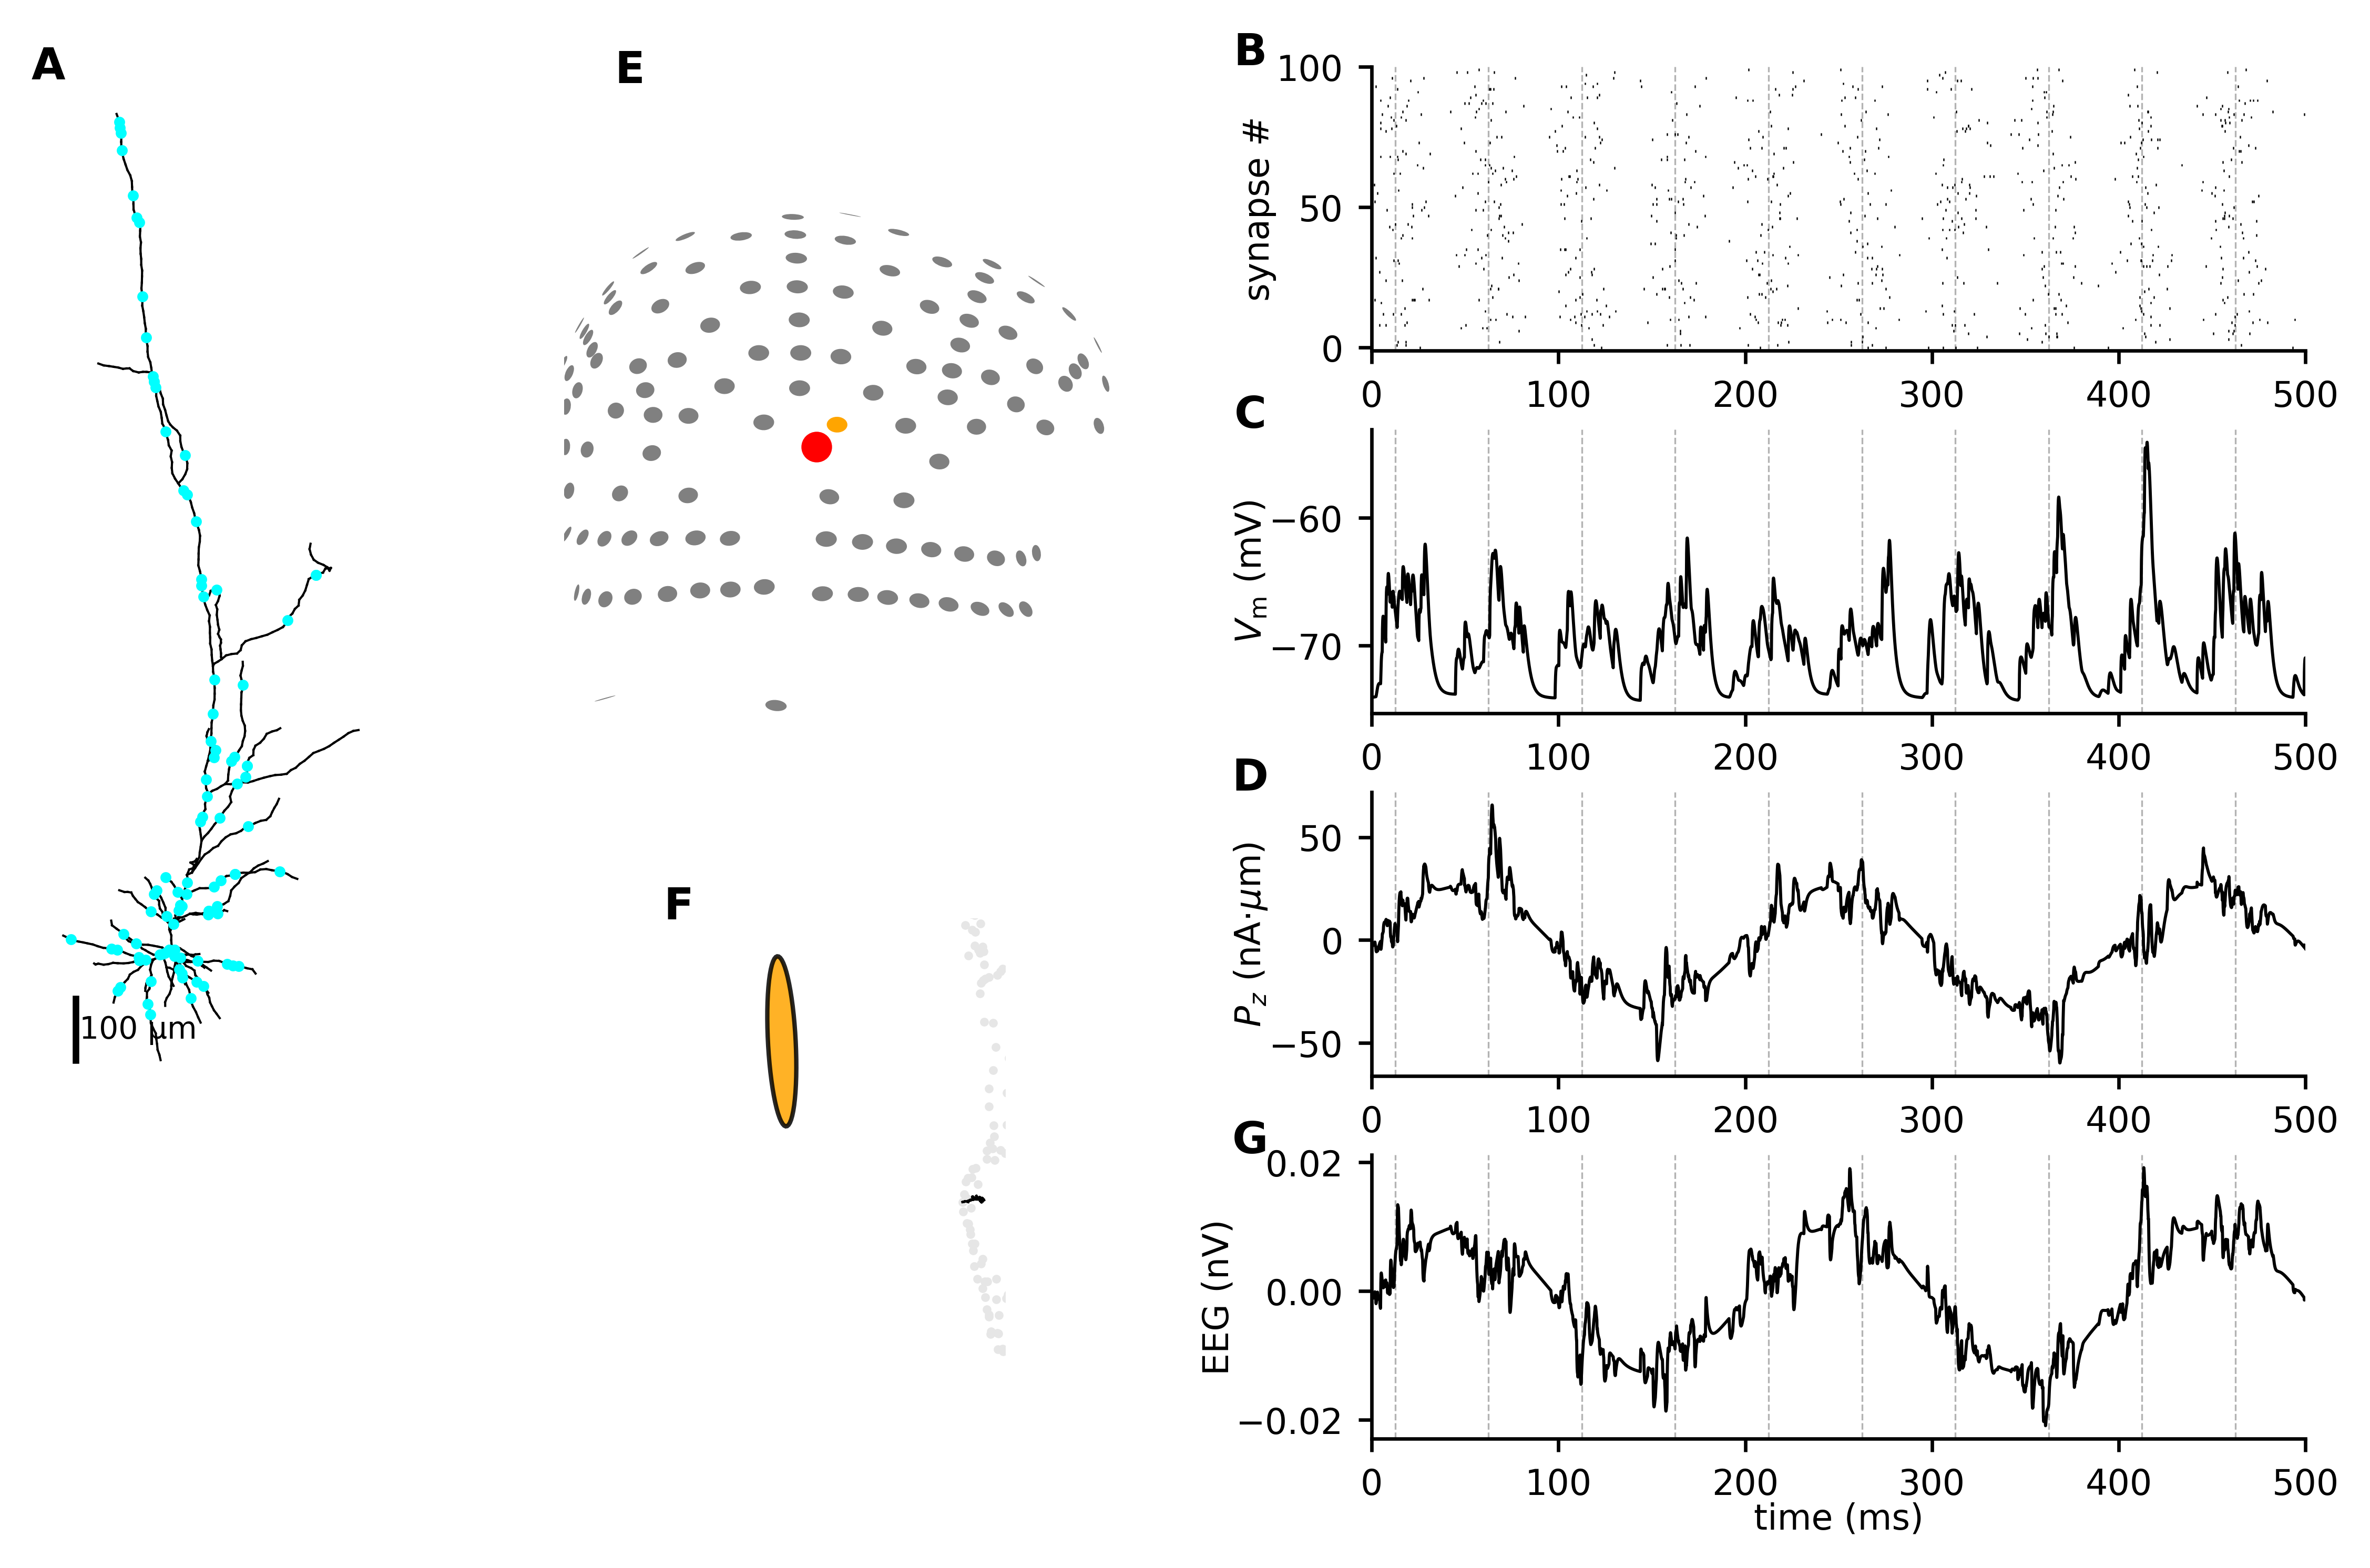

In [13]:
plt.close("all")
fig = plt.figure(figsize=[8, 5])
fig.subplots_adjust(hspace=0.6)

# ---- left column: morphology, 3D head, cortical cross-section ----
ax_neur = fig.add_axes([0.02, 0.30, 0.24, 0.66], aspect=1, frameon=False,
                       xticks=[], yticks=[])
ax_head = fig.add_axes([0.28, 0.50, 0.24, 0.46], projection='3d',
                       facecolor="none", computed_zorder=False)
ax_head.set(xlim=[-80, 80], ylim=[-70, 70], zlim=[-70, 70])
ax_head.set_xticks([]); ax_head.set_yticks([]); ax_head.set_zticks([])
ax_geom = fig.add_axes([0.28, 0.06, 0.22, 0.36], aspect=1, frameon=False,
                       xlim=[dipole_loc[0] - 20, dipole_loc[0] + 3],
                       ylim=[dipole_loc[2] - 20, dipole_loc[2] + 20],
                       xticks=[], yticks=[])

# ---- right column: time series (shared time axis) ----
ax_in = fig.add_axes([0.60, 0.78, 0.37, 0.18], ylabel="synapse #")
ax_vm = fig.add_axes([0.60, 0.55, 0.37, 0.18], ylabel=r"$V_{\rm m}$ (mV)")
ax_p = fig.add_axes([0.60, 0.32, 0.37, 0.18], ylabel=r"$P_z$ (nA$\cdot\mu$m)")
ax_eeg = fig.add_axes([0.60, 0.09, 0.37, 0.18], xlabel="time (ms)", ylabel="EEG (nV)")

# --- A: morphology + synapse locations ---
ax_neur.plot(cell_x_up.T, cell_z_up.T, c='k', lw=0.5, zorder=1)
ax_neur.plot(syn_pos_x, syn_pos_z, 'o', c='cyan', ms=2.5, mec='none', zorder=2)
ax_neur.plot([cell_x_up.min() + 20, cell_x_up.min() + 20], [cell_z_up.min(), cell_z_up.min() + 100],
             c='k', lw=1.5)
ax_neur.text(cell_x_up.min() + 26, cell_z_up.min() + 50, "100 µm", va='center', fontsize=7)

# --- E: 3D head, left-lateral view, MTG source marked ---
#ax_head.plot_trisurf(x_ctx, y_ctx, z_ctx, triangles=cortex_tri, color="pink", zorder=0)
#ax_head.plot_trisurf(x_h, y_h, z_h, triangles=head_tri, color="#c87137",
#                     zorder=0, alpha=0.15)
for elec_idx in range(num_elecs):

    fc = 'orange' if elec_idx == eeg_elec_idx else 'gray'
    disc = Circle((0, 0), 4, facecolor=fc, zorder=-elecs[0, elec_idx])
    ax_head.add_patch(disc)
    pathpatch_2d_to_3d(disc, z=0, normal=elecs[3:, elec_idx])
    pathpatch_translate(disc, elecs[:3, elec_idx])
_marker = cortex[:, vertex_idx].copy(); _marker[0] -= 18   # push out toward viewer
ax_head.plot([_marker[0]], [_marker[1]], [_marker[2]], 'o', c='red', ms=6, zorder=1e4)
ax_head.view_init(elev=0, azim=0)
ax_head.axis('off')

# --- F: cortical cross-section through the source, with source arrow ---
threshold = 5
xz_plane_idxs = np.where(np.abs(cortex[1, :] - dipole_loc[1]) < threshold)[0]
ax_geom.scatter(cortex[0, xz_plane_idxs], cortex[2, xz_plane_idxs], s=1, c='0.9')
#ax_geom.plot(cortex[0, vertex_idx], cortex[2, vertex_idx], 'o', c='red', ms=5)

# The cell was already rotated onto the surface normal before simulation, so plot
# its compartments directly. Translate so the apical tip (most-outward point along
# the normal) sits at the cortical vertex, with the cell hanging inward.
_ctr = np.array([cell_x.mean(1), cell_y.mean(1), cell_z.mean(1)])
_tip = _ctr[:, np.argmax(_ctr.T @ nyhead.cortex_normal_vec)]
ax_geom.plot((cell_x - _tip[0]).T / 1000 + cortex[0, vertex_idx],
             (cell_z - _tip[2]).T / 1000 + cortex[2, vertex_idx], c='k', lw=0.5, zorder=1)

# EEG electrode (top_elec_idx) as its flat disc projected onto the x-z plane,
# so the oval reflects the electrode's orientation.
def elec_oval(pos, normal, r=6., npts=60):
    n = normal / np.linalg.norm(normal)
    ref = np.array([0, 0, 1.]) if abs(n[2]) < 0.9 else np.array([0, 1., 0])
    u = np.cross(n, ref); u /= np.linalg.norm(u)
    v = np.cross(n, u)
    th = np.linspace(0, 2 * np.pi, npts)
    return pos[:, None] + r * np.cos(th) * u[:, None] + r * np.sin(th) * v[:, None]

_ep = elec_oval(elecs[:3, eeg_elec_idx], elecs[3:, eeg_elec_idx], r=6.)
ax_geom.fill(_ep[0], _ep[2], facecolor='orange', edgecolor='k', lw=1,
             alpha=0.85, zorder=4)

#ax_geom.plot(cell_x.T / 1000 + cortex[0, vertex_idx], cell_z.T / 1000 + cortex[2, vertex_idx], c='k', lw=0.5, zorder=1)

#ax_geom.plot([-70, -50], [-75, -75], c='k', lw=2)
#ax_geom.text(-60, -80, "20 mm", ha='center', va="top", fontsize=7)

# --- B: presynaptic input raster (shows 20 Hz modulation) ---
ax_in.eventplot([st for st in syn_spike_times], colors='k', lineoffsets=np.arange(num_syns),
                linelengths=0.9, linewidths=0.3)
ax_in.set_ylim(-1, num_syns)
ax_in.set_xlim(0, tstop)

# --- C: somatic membrane potential with APs ---
ax_vm.plot(tvec, somav, 'k', lw=0.7)
ax_vm.plot(ap_times, np.full_like(ap_times, 30), 'r.', ms=4)
ax_vm.set_xlim(0, tstop)

# --- D: current dipole moment (P_z) ---
ax_p.plot(tvec, p_surf[2, :], 'k', lw=0.7)
ax_p.set_xlim(0, tstop)

# --- G: EEG at the closest electrode ---
ax_eeg.plot(tvec, eeg[eeg_elec_idx], 'k', lw=0.7)
ax_eeg.set_xlim(0, tstop)

# mark the modulation peaks on all time-series panels
for ax in [ax_in, ax_vm, ax_p, ax_eeg]:
    for pt in peak_times:
        ax.axvline(pt, ls='--', c='0.7', lw=0.4, zorder=0)

mark_subplots([ax_neur], "A", ypos=1.0, xpos=0.0)
mark_subplots([ax_in], "B", ypos=1.05, xpos=-0.13)
mark_subplots([ax_vm], "C", ypos=1.05, xpos=-0.13)
mark_subplots([ax_p], "D", ypos=1.05, xpos=-0.13)
fig.text(0.30, 0.95, "E", fontweight='demibold', fontsize=10)
mark_subplots([ax_geom], "F", ypos=1.02, xpos=0.0)
mark_subplots([ax_eeg], "G", ypos=1.05, xpos=-0.13)
simplify_axes([ax_in, ax_vm, ax_p, ax_eeg])

plt.savefig("ongoing_input_mtg_passive.png")
#plt.savefig("active_ongoing_input_mtg.pdf")

In [9]:
nyhead.lead_field.shape

(3, 74382, 231)